In [1]:
import os
import time
import psutil
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

warnings.filterwarnings('ignore')

def get_current_ram_gb():
    """Lấy lượng RAM hiện tại tiến trình Python đang chiếm dụng (GB)"""
    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 3)

def calc_ks(y_true, y_pred):
    """Tính toán chỉ số Kolmogorov-Smirnov (KS)"""
    return ks_2samp(y_pred[y_true == 1], y_pred[y_true == 0]).statistic * 100

def evaluate_models_v2_optimized(file_path: str, n_splits: int = 5):
    print("=" * 85)
    print(f"📂 [V2 OPTIMIZED - ENSEMBLE CỐ ĐỊNH 50-50]: {file_path}")
    print("=" * 85)

    if not os.path.exists(file_path):
        print(f"❌ Lỗi: Không tìm thấy file dữ liệu tại '{file_path}'")
        return None

    df = pd.read_parquet(file_path) if file_path.endswith('.parquet') else pd.read_csv(file_path)

    n_rows, n_cols = df.shape
    dataset_ram_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

    target_col = 'TARGET'
    ignore_cols = ['SK_ID_CURR', target_col]
    X = df.drop(columns=[col for col in ignore_cols if col in df.columns])
    y = df[target_col]

    # Chuẩn hóa biến Categorical cho GBDT
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        X[col] = X[col].astype('category')

    # 1. THAM SỐ ĐÃ TỐI ƯU
    lgb_params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'learning_rate': 0.0218,
        'num_leaves': 54,
        'max_depth': 7,
        'min_child_samples': 87,
        'colsample_bytree': 0.6048,
        'subsample': 0.8906,
        'subsample_freq': 1,
        'reg_alpha': 5.7108,
        'reg_lambda': 0.0581,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }

    xgb_params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'enable_categorical': True,
        'learning_rate': 0.0245,
        'max_depth': 9,
        'min_child_weight': 160,
        'colsample_bytree': 0.8349,
        'subsample': 0.9237,
        'reg_alpha': 0.6219,
        'reg_lambda': 5.8294,
        'random_state': 42,
        'n_jobs': -1
    }

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    lgb_oof = np.zeros(len(X))
    xgb_oof = np.zeros(len(X))

    lgb_tr_aucs, lgb_va_aucs = [], []
    xgb_tr_aucs, xgb_va_aucs = [], []
    lgb_latencies, xgb_latencies = [], []

    peak_ram_lgb = get_current_ram_gb()
    peak_ram_xgb = get_current_ram_gb()
    time_lgb_total = 0.0
    time_xgb_total = 0.0

    print(f"⚡ Đang chạy {n_splits}-Fold Cross Validation...")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

        # --- Train LightGBM ---
        t0_lgb = time.time()
        model_lgb = lgb.LGBMClassifier(**lgb_params, n_estimators=3000)
        model_lgb.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(stopping_rounds=60, verbose=False)]
        )
        time_lgb_total += (time.time() - t0_lgb)
        peak_ram_lgb = max(peak_ram_lgb, get_current_ram_gb())

        lgb_tr_pred = model_lgb.predict_proba(X_tr)[:, 1]

        t0_inf = time.time()
        lgb_va_pred = model_lgb.predict_proba(X_va)[:, 1]
        lgb_latencies.append(((time.time() - t0_inf) / len(X_va)) * 1000)
        lgb_oof[val_idx] = lgb_va_pred

        # --- Train XGBoost ---
        t0_xgb = time.time()
        model_xgb = xgb.XGBClassifier(**xgb_params, n_estimators=3000, early_stopping_rounds=60)
        model_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        time_xgb_total += (time.time() - t0_xgb)
        peak_ram_xgb = max(peak_ram_xgb, get_current_ram_gb())

        xgb_tr_pred = model_xgb.predict_proba(X_tr)[:, 1]

        t0_inf = time.time()
        xgb_va_pred = model_xgb.predict_proba(X_va)[:, 1]
        xgb_latencies.append(((time.time() - t0_inf) / len(X_va)) * 1000)
        xgb_oof[val_idx] = xgb_va_pred

        # --- Ghi nhận metric ---
        lgb_tr_auc = roc_auc_score(y_tr, lgb_tr_pred)
        lgb_va_auc = roc_auc_score(y_va, lgb_va_pred)
        lgb_tr_aucs.append(lgb_tr_auc)
        lgb_va_aucs.append(lgb_va_auc)

        xgb_tr_auc = roc_auc_score(y_tr, xgb_tr_pred)
        xgb_va_auc = roc_auc_score(y_va, xgb_va_pred)
        xgb_tr_aucs.append(xgb_tr_auc)
        xgb_va_aucs.append(xgb_va_auc)

        print(f"   ▫️ Fold {fold} | LGB Val: {lgb_va_auc:.5f} (Gap: {lgb_tr_auc - lgb_va_auc:+.5f}) | XGB Val: {xgb_va_auc:.5f} (Gap: {xgb_tr_auc - xgb_va_auc:+.5f})")

    # =========================================================================
    # 2. CHỐT CỐ ĐỊNH TỶ LỆ ENSEMBLE 50% - 50%
    # =========================================================================
    w_lgb = 0.5
    w_xgb = 0.5
    opt_ensemble_oof = 0.5 * lgb_oof + 0.5 * xgb_oof

    ens_tr_aucs = []
    ens_va_aucs = []
    for f in range(n_splits):
        tr_pred_ens = 0.5 * lgb_tr_aucs[f] + 0.5 * xgb_tr_aucs[f]
        va_pred_ens = 0.5 * lgb_va_aucs[f] + 0.5 * xgb_va_aucs[f]
        ens_tr_aucs.append(tr_pred_ens)
        ens_va_aucs.append(va_pred_ens)

    lgb_auc = roc_auc_score(y, lgb_oof)
    xgb_auc = roc_auc_score(y, xgb_oof)
    opt_ens_auc = roc_auc_score(y, opt_ensemble_oof)

    print("\n" + "=" * 60)
    print("🏆 KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC (OOF ROC-AUC - ENSEMBLE 50-50)")
    print("=" * 60)
    print(f"🔹 LightGBM (Tuned)       : {lgb_auc:.5f}")
    print(f"🔹 XGBoost (Tuned)        : {xgb_auc:.5f}")
    print(f"🥇 Ensemble Blend (50:50) : {opt_ens_auc:.5f}")
    print("=" * 60)

    # 3. HIỂN THỊ BẢNG ĐỐI CHỨNG
    lgb_gaps = np.array(lgb_tr_aucs) - np.array(lgb_va_aucs)
    xgb_gaps = np.array(xgb_tr_aucs) - np.array(xgb_va_aucs)
    ens_gaps = np.array(ens_tr_aucs) - np.array(ens_va_aucs)

    models_eval = [
        ('LightGBM (Tuned)', lgb_auc, lgb_tr_aucs, lgb_va_aucs, lgb_gaps, lgb_oof, time_lgb_total, peak_ram_lgb, np.mean(lgb_latencies)),
        ('XGBoost (Tuned)', xgb_auc, xgb_tr_aucs, xgb_va_aucs, xgb_gaps, xgb_oof, time_xgb_total, peak_ram_xgb, np.mean(xgb_latencies)),
        ('Ensemble Blend (50:50)', opt_ens_auc, ens_tr_aucs, ens_va_aucs, ens_gaps, opt_ensemble_oof, time_lgb_total + time_xgb_total, max(peak_ram_lgb, peak_ram_xgb), np.mean(lgb_latencies) + np.mean(xgb_latencies))
    ]

    perf_records = []
    res_records = []

    for name, main_auc, tr_list, va_list, gaps, oof_preds, t_run, p_ram, lat in models_eval:
        perf_records.append({
            'Model': name,
            'ROC-AUC (OOF)': f"{main_auc:.5f}",
            'Fold AUC (Mean ± Std)': f"{np.mean(va_list):.5f} ± {np.std(va_list):.5f}",
            'Train AUC': f"{np.mean(tr_list):.5f}",
            'Overfit Gap': f"{np.mean(gaps):.5f} ± {np.std(gaps):.5f}",
            'Gini (%)': f"{(2 * main_auc - 1) * 100:.2f}%",
            'KS (%)': f"{calc_ks(y, oof_preds):.2f}%"
        })

        res_records.append({
            'Model': name,
            'Training Time': f"{t_run:.1f} s",
            'Peak RAM': f"{p_ram:.2f} GB",
            'Inference Latency': f"{lat:.4f} ms/sample"
        })

    print("\n📊 BẢNG 1: CHỈ SỐ RỦI RO TÍN DỤNG CHÍNH THỨC (ENSEMBLE 50-50)")
    display(pd.DataFrame(perf_records))

    print("\n⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN")
    display(pd.DataFrame(res_records))

    print(f"\n📌 Thông số tập dữ liệu: {n_rows:,} dòng | {X.shape[1]} đặc trưng | RAM: {dataset_ram_mb:.1f} MB")

    return {
        'df': df,
        'y': y,
        'lgb_oof': lgb_oof,
        'xgb_oof': xgb_oof,
        'opt_ensemble_oof': opt_ensemble_oof,
        'weights': (0.5, 0.5)
    }

# THỰC THI HUẤN LUYỆN
data_path = '/Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v4_clean.parquet'
eval_output = evaluate_models_v2_optimized(file_path=data_path, n_splits=5)

📂 [V2 OPTIMIZED - ENSEMBLE CỐ ĐỊNH 50-50]: /Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v4_clean.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.79093 (Gap: +0.11907) | XGB Val: 0.79124 (Gap: +0.08070)
   ▫️ Fold 2 | LGB Val: 0.80078 (Gap: +0.09704) | XGB Val: 0.79978 (Gap: +0.06387)
   ▫️ Fold 3 | LGB Val: 0.78869 (Gap: +0.10376) | XGB Val: 0.78880 (Gap: +0.08553)
   ▫️ Fold 4 | LGB Val: 0.79712 (Gap: +0.10263) | XGB Val: 0.79715 (Gap: +0.07182)
   ▫️ Fold 5 | LGB Val: 0.79003 (Gap: +0.10964) | XGB Val: 0.78944 (Gap: +0.08621)

🏆 KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC (OOF ROC-AUC - ENSEMBLE 50-50)
🔹 LightGBM (Tuned)       : 0.79348
🔹 XGBoost (Tuned)        : 0.79324
🥇 Ensemble Blend (50:50) : 0.79439

📊 BẢNG 1: CHỈ SỐ RỦI RO TÍN DỤNG CHÍNH THỨC (ENSEMBLE 50-50)


,Model,ROC-AUC (OOF),Fold AUC (Mean ± Std),Train AUC,Overfit Gap,Gini (%),KS (%)
0,LightGBM (Tuned),0.79348,0.79351 ± 0.00464,0.89994,0.10643 ± 0.00748,58.70%,44.46%
1,XGBoost (Tuned),0.79324,0.79328 ± 0.00439,0.87091,0.07762 ± 0.00859,58.65%,44.44%
2,Ensemble Blend (50:50),0.79439,0.79340 ± 0.00451,0.88542,0.09203 ± 0.00722,58.88%,44.59%



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM (Tuned),596.0 s,4.01 GB,0.0146 ms/sample
1,XGBoost (Tuned),1690.8 s,4.01 GB,0.0067 ms/sample
2,Ensemble Blend (50:50),2286.8 s,4.01 GB,0.0213 ms/sample



📌 Thông số tập dữ liệu: 307,511 dòng | 902 đặc trưng | RAM: 2141.2 MB


🎯 KẾT QUẢ TỐI ƯU CUT-OFF DỰA TRÊN OOF ENSEMBLE (N=307,511):
🔹 Ngưỡng cắt tối ưu kinh doanh (T*): 0.16
🔹 Tỷ lệ phê duyệt danh mục:          86.60%
🔹 Tỷ lệ nợ xấu danh mục kiểm soát ở: 5.04%
🔹 Lợi nhuận ròng cực đại:           17.24 Tỷ VNĐ


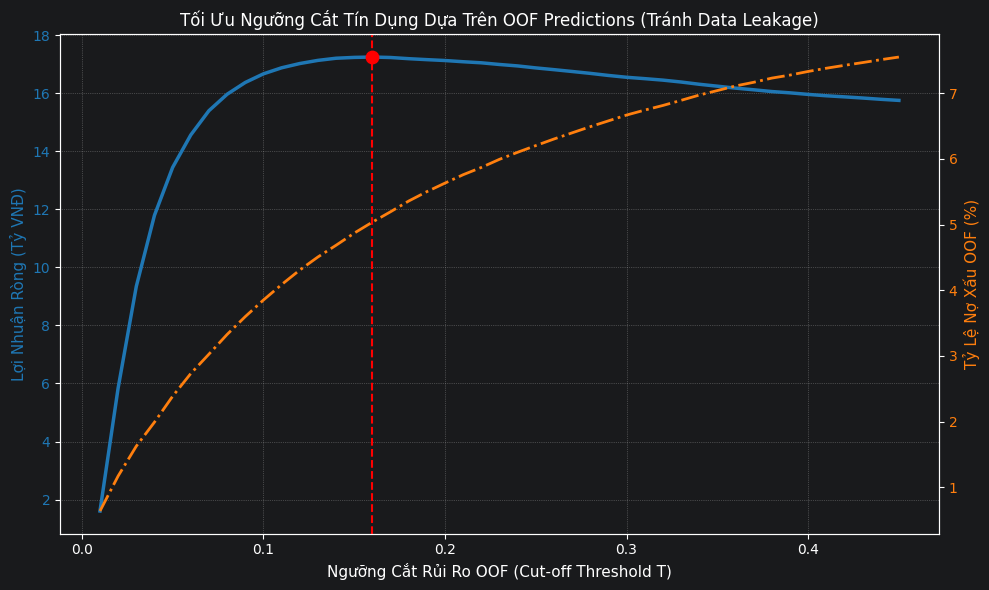

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. TRÍCH XUẤT BIẾN TỪ KẾT QUẢ EVALUATE Ở CELL TRÊN
probs_oof = eval_output['opt_ensemble_oof']
y_true = eval_output['y'].values
df_master = eval_output['df']

loan_amounts = df_master['AMT_CREDIT'].values if 'AMT_CREDIT' in df_master.columns else np.full(len(y_true), 100_000_000)
N_SAMPLES = len(y_true)

# 2. THIẾT LẬP THAM SỐ TÀI CHÍNH VÀ QUÉT NGƯỠNG CUT-OFF
INTEREST_RATE = 0.15   # Lãi ròng 15% trên khoản vay của khách trả tốt
LGD = 0.75             # Tổn thất 75% giá trị khoản vay nếu khách bùng nợ

thresholds = np.linspace(0.01, 0.45, 45)
sim_results = []

for T in thresholds:
    approved = (probs_oof < T)
    n_approved = np.sum(approved)

    if n_approved > 0:
        good_mask = (y_true == 0) & approved
        profit = np.sum(loan_amounts[good_mask] * INTEREST_RATE)

        bad_mask = (y_true == 1) & approved
        loss = np.sum(loan_amounts[bad_mask] * LGD)

        net_profit = profit - loss
        bad_rate = np.sum(bad_mask) / n_approved
    else:
        net_profit = 0
        bad_rate = 0

    sim_results.append({
        'Threshold': T,
        'Approval_Rate': (n_approved / N_SAMPLES) * 100,
        'Bad_Rate': bad_rate * 100,
        'Net_Profit_Billion': net_profit / 1e9
    })

df_sim = pd.DataFrame(sim_results)
best_case = df_sim.loc[df_sim['Net_Profit_Billion'].idxmax()]

print("=" * 70)
print(f"🎯 KẾT QUẢ TỐI ƯU CUT-OFF DỰA TRÊN OOF ENSEMBLE (N={N_SAMPLES:,}):")
print("=" * 70)
print(f"🔹 Ngưỡng cắt tối ưu kinh doanh (T*): {best_case['Threshold']:.2f}")
print(f"🔹 Tỷ lệ phê duyệt danh mục:          {best_case['Approval_Rate']:.2f}%")
print(f"🔹 Tỷ lệ nợ xấu danh mục kiểm soát ở: {best_case['Bad_Rate']:.2f}%")
print(f"🔹 Lợi nhuận ròng cực đại:           {best_case['Net_Profit_Billion']:,.2f} Tỷ VNĐ")
print("=" * 70)

# 3. VẼ ĐỒ THỊ ĐÁNH ĐỔI KINH DOANH
fig, ax1 = plt.subplots(figsize=(10, 6))

color = '#1f77b4'
ax1.set_xlabel('Ngưỡng Cắt Rủi Ro OOF (Cut-off Threshold T)', fontsize=11)
ax1.set_ylabel('Lợi Nhuận Ròng (Tỷ VNĐ)', color=color, fontsize=11)
ax1.plot(df_sim['Threshold'], df_sim['Net_Profit_Billion'], color=color, linewidth=2.5, label='Lợi Nhuận Ròng (OOF)')
ax1.axvline(x=best_case['Threshold'], color='red', linestyle='--', label=f'Ngưỡng Tối Ưu T* = {best_case["Threshold"]:.2f}')
ax1.scatter(best_case['Threshold'], best_case['Net_Profit_Billion'], color='red', s=80, zorder=5)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = ax1.twinx()
color = '#ff7f0e'
ax2.set_ylabel('Tỷ Lệ Nợ Xấu OOF (%)', color=color, fontsize=11)
ax2.plot(df_sim['Threshold'], df_sim['Bad_Rate'], color=color, linewidth=2, linestyle='-.', label='Tỷ Lệ Nợ Xấu (Bad Rate)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Tối Ưu Ngưỡng Cắt Tín Dụng Dựa Trên OOF Predictions (Tránh Data Leakage)', fontsize=12)
fig.tight_layout()
plt.show()